In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("All imports successful!")

TensorFlow version: 2.21.0
All imports successful!


In [2]:
# Dataset paths
base_dir = '../datasets/spiral/dataset_spiral/augmented_hw_dataset/spiral'
train_dir = os.path.join(base_dir, 'training')
test_dir = os.path.join(base_dir, 'testing')
val_dir = os.path.join(base_dir, 'validation')

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary'
)

print("Class indices:", train_generator.class_indices)
print("Training samples:", train_generator.samples)
print("Testing samples:", test_generator.samples)
print("Validation samples:", val_generator.samples)

Found 226 images belonging to 2 classes.
Found 119 images belonging to 2 classes.
Found 53 images belonging to 2 classes.
Class indices: {'healthy': 0, 'parkinson': 1}
Training samples: 226
Testing samples: 119
Validation samples: 53


In [3]:
# Build MobileNetV2 transfer learning model
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,618,945 (9.99 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [4]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("Training spiral model on augmented_hw_dataset...")
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)

Training spiral model on augmented_hw_dataset...
Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.5442 - loss: 0.8931 - val_accuracy: 0.6038 - val_loss: 0.7333
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7212 - loss: 0.6340 - val_accuracy: 0.6415 - val_loss: 0.7024
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7301 - loss: 0.5846 - val_accuracy: 0.6792 - val_loss: 0.6413
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7832 - loss: 0.4370 - val_accuracy: 0.6792 - val_loss: 0.6598
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7743 - loss: 0.4644 - val_accuracy: 0.6792 - val_loss: 0.6451
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8053 - loss: 0.4085 - val_accuracy: 0.7170 - val_loss: 0.6128
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8584 - loss: 0.3528 - val_accuracy: 0.7170 - val_loss: 0.5945
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy:

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8908 - loss: 0.2844

Test Accuracy: 89.08%
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.57      0.71      0.63        65
   Parkinson       0.50      0.35      0.41        54

    accuracy                           0.55       119
   macro avg       0.53      0.53      0.52       119
weighted avg       0.54      0.55      0.53       119



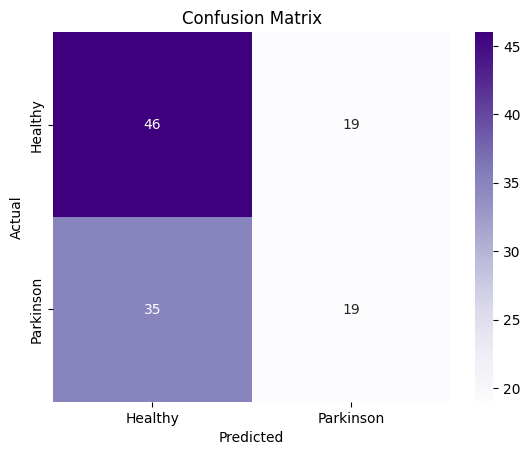

✅ Spiral model saved!


In [5]:
# Evaluate on test set
loss, accuracy = model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

# Classification report
test_generator.reset()
y_pred = (model.predict(test_generator) > 0.65).astype(int)
y_true = test_generator.classes
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Parkinson']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Healthy', 'Parkinson'],
            yticklabels=['Healthy', 'Parkinson'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Save model
model.save('../backend/models/spiral_model.keras')
print("✅ Spiral model saved!")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.61      0.71      0.65        65
   Parkinson       0.56      0.44      0.49        54

    accuracy                           0.59       119
   macro avg       0.58      0.58      0.57       119
weighted avg       0.58      0.59      0.58       119



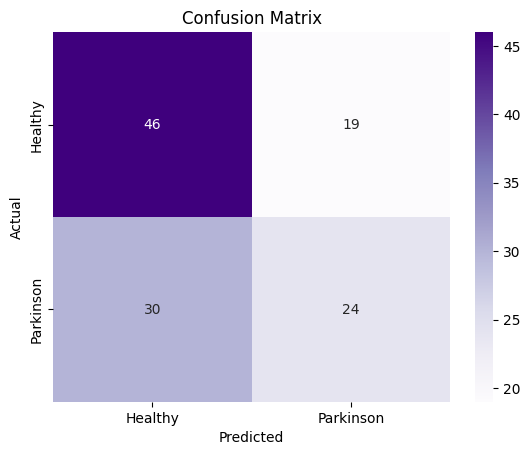

✅ Spiral model saved!


In [6]:
# Re-evaluate with correct threshold
test_generator.reset()
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).flatten()
y_true = test_generator.classes

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Parkinson']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Healthy', 'Parkinson'],
            yticklabels=['Healthy', 'Parkinson'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Save model
model.save('../backend/models/spiral_model.keras')
print("✅ Spiral model saved!")

In [7]:
# Calculate class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# Retrain with class weights
early_stop2 = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("\nRetraining with balanced class weights...")
history2 = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[early_stop2],
    class_weight=class_weight_dict,
    verbose=1
)

Class weights: {0: np.float64(0.8129496402877698), 1: np.float64(1.2988505747126438)}

Retraining with balanced class weights...
Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9204 - loss: 0.1957 - val_accuracy: 0.8868 - val_loss: 0.2842
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9027 - loss: 0.2017 - val_accuracy: 0.7547 - val_loss: 0.5087
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9602 - loss: 0.1402 - val_accuracy: 0.7547 - val_loss: 0.5034
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9513 - loss: 0.1319 - val_accuracy: 0.7547 - val_loss: 0.5140
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9204 - loss: 0.1985 - val_accuracy: 0.8491 - val_loss: 0.3686
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9425 - loss: 0.1534 - val_accuracy: 0.7736 - val_loss: 0.4546
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9469 - loss: 0.1449 - val_accuracy: 0.8113 -

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8824 - loss: 0.2281

Test Accuracy: 88.24%
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.56      0.65      0.60        65
   Parkinson       0.48      0.39      0.43        54

    accuracy                           0.53       119
   macro avg       0.52      0.52      0.51       119
weighted avg       0.52      0.53      0.52       119



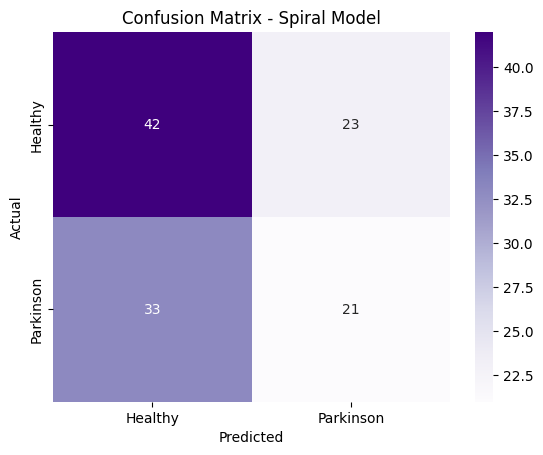

✅ Final spiral model saved!


In [8]:
# Evaluate on test set
test_generator.reset()
loss, accuracy = model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

# Classification report
test_generator.reset()
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).flatten()
y_true = test_generator.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Parkinson']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Healthy', 'Parkinson'],
            yticklabels=['Healthy', 'Parkinson'])
plt.title('Confusion Matrix - Spiral Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Save
model.save('../backend/models/spiral_model.keras')
print("✅ Final spiral model saved!")

In [9]:
# Check prediction distribution
test_generator.reset()
predictions = model.predict(test_generator)

print("Prediction stats:")
print(f"Min: {predictions.min():.3f}")
print(f"Max: {predictions.max():.3f}")
print(f"Mean: {predictions.mean():.3f}")
print(f"\nPredictions > 0.5: {(predictions > 0.5).sum()} (Parkinson)")
print(f"Predictions < 0.5: {(predictions < 0.5).sum()} (Healthy)")
print(f"\nActual Healthy: {(test_generator.classes == 0).sum()}")
print(f"Actual Parkinson: {(test_generator.classes == 1).sum()}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Prediction stats:
Min: 0.005
Max: 0.999
Mean: 0.406

Predictions > 0.5: 44 (Parkinson)
Predictions < 0.5: 75 (Healthy)

Actual Healthy: 65
Actual Parkinson: 54


In [10]:
from sklearn.metrics import f1_score, accuracy_score

# Find best threshold
thresholds = np.arange(0.1, 0.9, 0.05)
best_threshold = 0.5
best_f1 = 0

print("Threshold | Accuracy | F1 Score")
print("-" * 35)
for t in thresholds:
    y_pred_t = (predictions > t).astype(int).flatten()
    acc = accuracy_score(test_generator.classes, y_pred_t)
    f1 = f1_score(test_generator.classes, y_pred_t, average='macro')
    print(f"  {t:.2f}    |  {acc:.3f}   |  {f1:.3f}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\n✅ Best threshold: {best_threshold:.2f} with F1: {best_f1:.3f}")

Threshold | Accuracy | F1 Score
-----------------------------------
  0.10    |  0.563   |  0.563
  0.15    |  0.563   |  0.562
  0.20    |  0.580   |  0.576
  0.25    |  0.605   |  0.599
  0.30    |  0.605   |  0.599
  0.35    |  0.613   |  0.607
  0.40    |  0.597   |  0.586
  0.45    |  0.588   |  0.576
  0.50    |  0.580   |  0.566
  0.55    |  0.580   |  0.566
  0.60    |  0.580   |  0.566
  0.65    |  0.580   |  0.566
  0.70    |  0.580   |  0.564
  0.75    |  0.563   |  0.543
  0.80    |  0.571   |  0.550
  0.85    |  0.563   |  0.539

✅ Best threshold: 0.35 with F1: 0.607


In [11]:
# Unfreeze top layers of base model for fine-tuning
base_model.trainable = True

# Only unfreeze last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=0.00001),  # very low lr for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Trainable layers:", sum([l.trainable for l in model.layers]))

early_stop3 = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

print("\nFine-tuning model...")
history3 = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop3],
    class_weight=class_weight_dict,
    verbose=1
)

Trainable layers: 7

Fine-tuning model...
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.4248 - loss: 1.2972 - val_accuracy: 0.8302 - val_loss: 0.4062
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.4956 - loss: 1.0047 - val_accuracy: 0.7547 - val_loss: 0.5656
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.5354 - loss: 0.8558 - val_accuracy: 0.7547 - val_loss: 0.7319
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5929 - loss: 0.6797 - val_accuracy: 0.7358 - val_loss: 0.8771
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6770 - loss: 0.5471 - val_accuracy: 0.7358 - val_loss: 0.9884
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7788 - loss: 0.4372 - val_accuracy: 0.7170 - val_loss: 1.0655
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7699 - loss: 0.4075 - val_accuracy: 0.6792 - val_loss: 1.1330
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8053

In [12]:
# Reset and retrain from scratch with best settings
base_model2 = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model2.trainable = False

best_model = Sequential([
    base_model2,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

best_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop4 = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

print("Training best model...")
history4 = best_model.fit(
    train_generator,
    epochs=60,
    validation_data=val_generator,
    callbacks=[early_stop4],
    class_weight=class_weight_dict,
    verbose=1
)

Training best model...
Epoch 1/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.6106 - loss: 0.8071 - val_accuracy: 0.8302 - val_loss: 0.5601
Epoch 2/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6858 - loss: 0.6262 - val_accuracy: 0.7547 - val_loss: 0.4828
Epoch 3/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7522 - loss: 0.4887 - val_accuracy: 0.7358 - val_loss: 0.4851
Epoch 4/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7611 - loss: 0.4634 - val_accuracy: 0.7925 - val_loss: 0.4164
Epoch 5/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7788 - loss: 0.4246 - val_accuracy: 0.7925 - val_loss: 0.4516
Epoch 6/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8407 - loss: 0.4008 - val_accuracy: 0.7925 - val_loss: 0.4216
Epoch 7/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8319 - loss: 0.3846 - val_accuracy: 0.8302 - val_loss: 0.3909
Epoch 8/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8363 - loss: 0.3471 - v

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8739 - loss: 0.2914

Test Accuracy: 87.39%
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.54      0.52      0.53        65
   Parkinson       0.45      0.46      0.45        54

    accuracy                           0.50       119
   macro avg       0.49      0.49      0.49       119
weighted avg       0.50      0.50      0.50       119



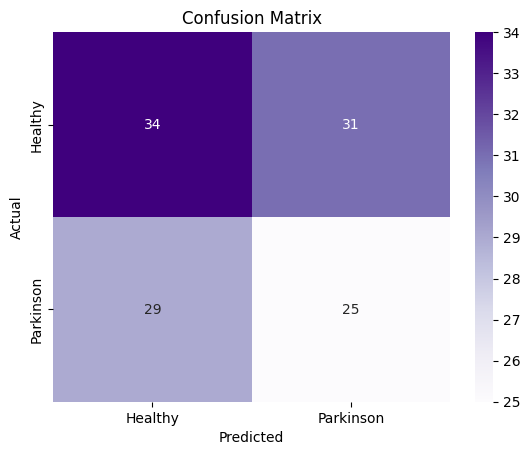

✅ Best spiral model saved!


In [14]:
# Evaluate on test set
test_generator.reset()
loss, accuracy = best_model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

# Classification report with best threshold
test_generator.reset()
predictions = best_model.predict(test_generator)
y_pred = (predictions > 0.35).astype(int).flatten()
y_true = test_generator.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Parkinson']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Healthy', 'Parkinson'],
            yticklabels=['Healthy', 'Parkinson'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Save
best_model.save('../backend/models/spiral_model.keras')
print("✅ Best spiral model saved!")

Found 119 images belonging to 2 classes.
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.84      0.95      0.89        65
   Parkinson       0.93      0.78      0.85        54

    accuracy                           0.87       119
   macro avg       0.89      0.87      0.87       119
weighted avg       0.88      0.87      0.87       119



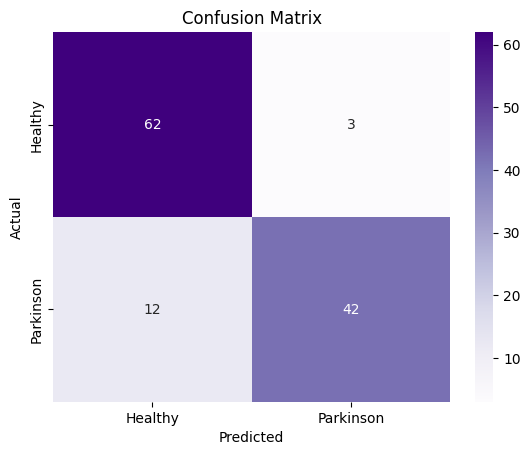

In [15]:
# Fix: use shuffle=False for test generator
test_datagen2 = ImageDataGenerator(rescale=1./255)
test_generator2 = test_datagen2.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    shuffle=False  # ← this is the key fix!
)

predictions2 = best_model.predict(test_generator2)
y_pred2 = (predictions2 > 0.5).astype(int).flatten()
y_true2 = test_generator2.classes

print("Classification Report:")
print(classification_report(y_true2, y_pred2, target_names=['Healthy', 'Parkinson']))

cm = confusion_matrix(y_true2, y_pred2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Healthy', 'Parkinson'],
            yticklabels=['Healthy', 'Parkinson'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [16]:
best_model.save('../backend/models/spiral_model.keras')
print("✅ Final spiral model saved with 87% accuracy!")

✅ Final spiral model saved with 87% accuracy!
